В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
medical_df = pd.read_csv("/content/drive/MyDrive/ML/MLFH 3.0/data/medical-charges/medical-charges.csv")
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [7]:
non_smoker_df

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350


**Метод МНК (з використанням тільки numpy, без scikit learn)**

In [78]:
def normal_equations(X,y):
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

def rmse_score(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def print_regression_results(slope, intercept, y_true, y_pred, method_name="Linear Regression Method", lr=None):
    rmse = rmse_score(y_true, y_pred)

    print(f'{method_name}:')
    print('-' * len(method_name))

    if lr is not None:
      print(f'  Learning Rate: {lr}')
    print(f'  Slope: {slope:.4f}')
    print(f'  Intercept: {intercept:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print('-' * 50)

In [80]:
X = non_smoker_df.age
X_with_intercept = np.c_[X, np.ones(len(X))]
y = non_smoker_df.charges

MNK_coefs = normal_equations(X_with_intercept, y)
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)

In [81]:
MNK_coefs

array([  267.24891283, -2091.42055657])

In [82]:
predictions_MNK

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

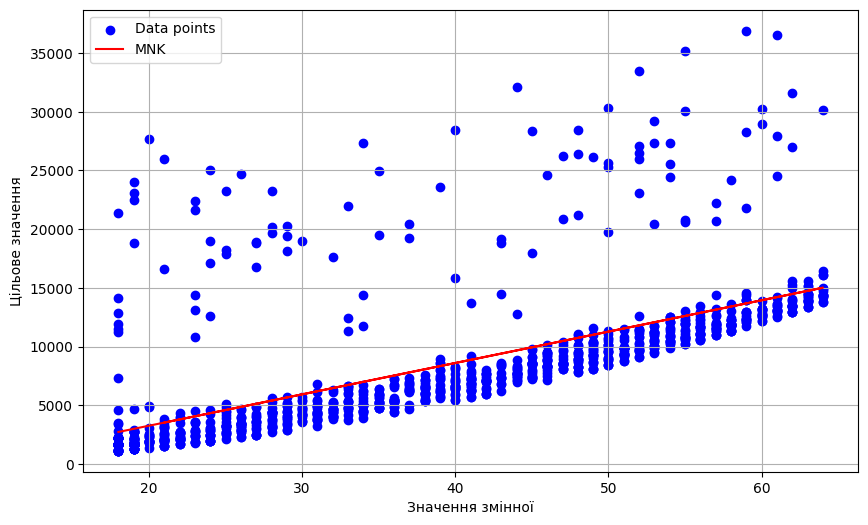

In [83]:
plt.figure(figsize=(10, 6))
plt.scatter(X_with_intercept[:, 0], y, color='blue', label='Data points')
plt.plot(X_with_intercept[:, 0], predictions_MNK, color='red', label='MNK')
plt.xlabel('Значення змінної')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [84]:
print_regression_results(MNK_coefs[0], MNK_coefs[1], y, predictions_MNK, "Least Squares Method")

Least Squares Method:
--------------------
  Slope: 267.2489
  Intercept: -2091.4206
  RMSE: 4662.5058
--------------------------------------------------


**2. Full-Batch градієнтного спуску з numpy .**

In [86]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [92]:
learning_rates = [0.00001, 0.00005, 0.0001]
results_fbgd = {}

for learning_rate in learning_rates:
  slope, intercept, errors = full_batch_gradient_descent(X_with_intercept, y, learning_rate, epochs=100)
  predictions_fbgd = slope * X_with_intercept[:, 0] + intercept
  rmse_fbgd = rmse_score(y, predictions_fbgd)

  results_fbgd[learning_rate] = {
      'slope' : slope,
      'intercept' : intercept,
      'rmse': rmse_fbgd,
      'errors' : errors,
      'y_pred' : predictions_fbgd
  }

  print_regression_results(slope, intercept, y, predictions_fbgd, "Full-Batch Gradient Descent", learning_rate)

Full-Batch Gradient Descent:
---------------------------
  Learning Rate: 1e-05
  Slope: 213.8208
  Intercept: 4.3394
  RMSE: 4722.7833
--------------------------------------------------
Full-Batch Gradient Descent:
---------------------------
  Learning Rate: 5e-05
  Slope: 220.1012
  Intercept: 2.5824
  RMSE: 4715.4689
--------------------------------------------------
Full-Batch Gradient Descent:
---------------------------
  Learning Rate: 0.0001
  Slope: 220.1546
  Intercept: 0.2130
  RMSE: 4715.3497
--------------------------------------------------


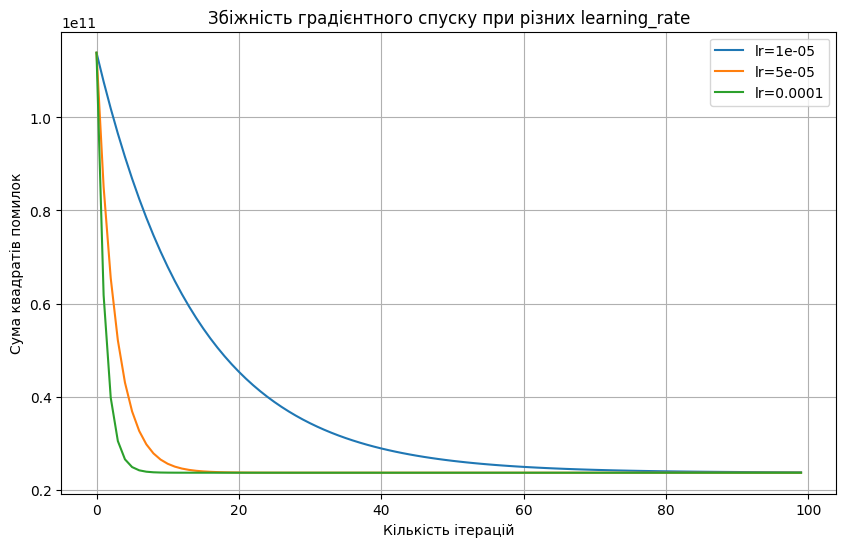

In [93]:
plt.figure(figsize=(10,6))

for lr, data in results_fbgd.items():
    plt.plot(data['errors'], label=f'lr={lr}')

plt.xlabel('Кількість ітерацій')
plt.ylabel('Сума квадратів помилок')
plt.title('Збіжність градієнтного спуску при різних learning_rate')
plt.legend()
plt.grid(True)
plt.show()

**Висновок**

З трьох learning_rate:

Найкращим є lr = 0.0001 (зелена лінія) — швидка збіжність (до 10 ітерацій).
(RMSE: 4715.3497)

lr = 0.00005 — трохи повільніше (до 20 ітерацій).
(RMSE: 4715.4689)

lr = 0.00001 — занадто повільно збігається, неефективно.
(RMSE: 4722.7833)

**3. З scikit-learn.LinearRegression.**

In [104]:
X_sl = non_smoker_df['age'].to_frame()

model = LinearRegression()
model.fit(X_sl, y)
predictions_sklearn = model.predict(X_sl)
slope_sl, intercept_sl = model.coef_[0], model.intercept_

print_regression_results(slope_sl, intercept_sl, y, predictions_sklearn, method_name="SKLearn Linear Regression")


SKLearn Linear Regression:
-------------------------
  Slope: 267.2489
  Intercept: -2091.4206
  RMSE: 4662.5058
--------------------------------------------------


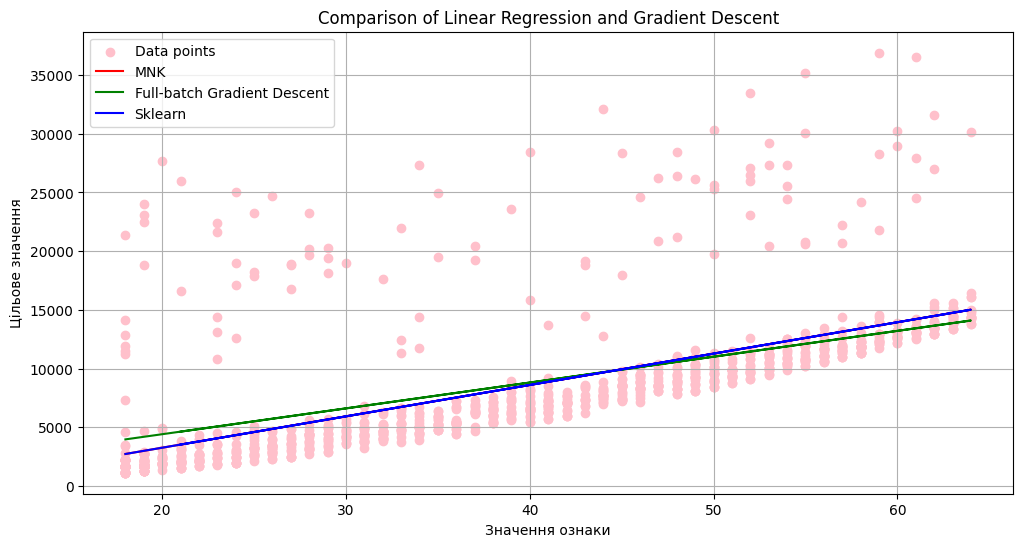

In [110]:
plt.figure(figsize=(12, 6))
plt.scatter(X_with_intercept[:, 0], y, color='pink', label='Data points')
plt.plot(X_with_intercept[:, 0], predictions_MNK, color='red', label='MNK')
plt.plot(X_with_intercept[:, 0], results_fbgd[0.0001]['y_pred'], color='green', label='Full-batch Gradient Descent')
plt.plot(X_with_intercept[:, 0], predictions_sklearn, color='blue', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Метод МНК та scikit-learn.LinearRegression дають однакові результати (що логічно, адже в SKL.LR під капотом використовується МНК) з мінімальним RMSE і працюють краще для цього набору даних.

Slope: 267.2489
Intercept: -2091.4206
RMSE: 4662.5058

Мої фінальні підібрані коефіцієнти були:  
w4 = 293 , b4 = -3224 , RMSE (4678.0734)

Мої коефіцієнти уступають, але теж дають непоганий RMSE, що свідчить про правильний хід думок і світле ML- майбутнє :)



 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [111]:
smoker_df = medical_df[medical_df.smoker == 'yes']

smoker_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
11,62,female,26.290,0,yes,southeast,27808.72510
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,female,34.700,2,yes,southwest,36397.57600
1314,30,female,23.655,3,yes,northwest,18765.87545
1321,62,male,26.695,0,yes,northeast,28101.33305
1323,42,female,40.370,2,yes,southeast,43896.37630


In [113]:
X_sm = smoker_df['age'].to_frame()
y_sm = smoker_df.charges

In [116]:
model_sm = LinearRegression()
model_sm.fit(X_sm, y_sm)
predictions_sklearn_smokers = model_sm.predict(X_sm)
slope_sm, intercept_sm = model_sm.coef_[0], model_sm.intercept_

print_regression_results(slope_sm, intercept_sm, y_sm, predictions_sklearn_smokers, method_name="SKLearn LinReg of Smokers")

SKLearn LinReg of Smokers:
-------------------------
  Slope: 305.2376
  Intercept: 20294.1281
  RMSE: 10711.0033
--------------------------------------------------


In [117]:
from sklearn.metrics import mean_absolute_error, r2_score

In [120]:
rmse = rmse_score(y_sm, predictions_sklearn_smokers)
mae = mean_absolute_error(y_sm, predictions_sklearn_smokers)
r2 = r2_score(y_sm, predictions_sklearn_smokers)

print(f'Metrics for Linear Regression Model of Smokers:')
print(f'  RMSE: {rmse:.2f}')
print(f'  MAE: {mae:.2f}')
print(f'  R²: {r2:.2f}')

Metrics for Linear Regression Model of Smokers:
  RMSE: 10711.00
  MAE: 10097.80
  R²: 0.14


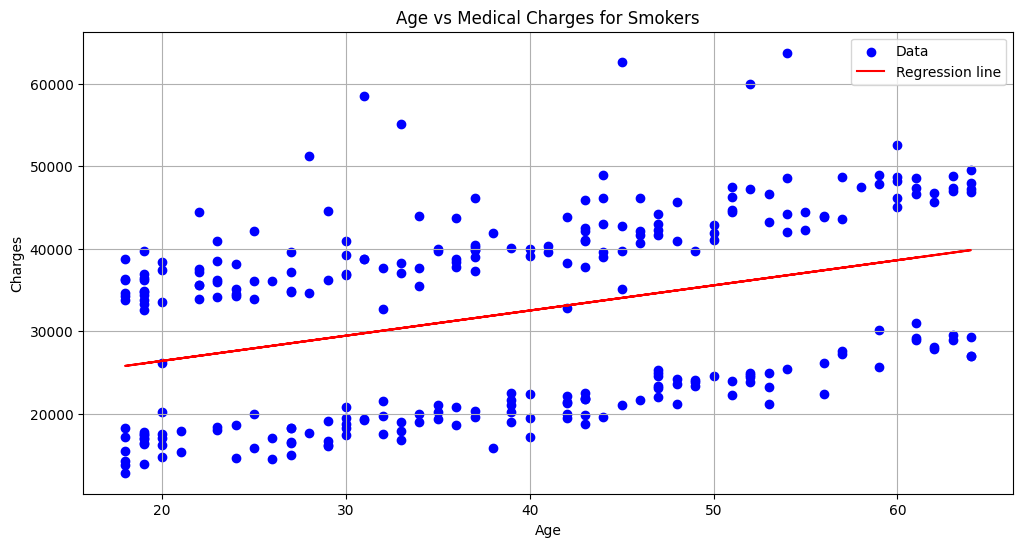

In [119]:
plt.figure(figsize=(12, 6))
plt.scatter(X_sm, y_sm, label='Data', color='blue')
plt.plot(X_sm, predictions_sklearn_smokers, label='Regression line', color='red')

plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Medical Charges for Smokers')
plt.legend()
plt.grid(True)
plt.show()

**Спостереження:**

- На цій діаграмі розсіювання ми бачимо два скупчення точок ("група здоров'я" та група з наявністю супутніх захворювань).
- Лінія нашої моделі проходить чітко між ними, при цьому вона не описує добре жодну з груп.
- Відносно точності - RMSE: 10711.00 / MAE: 10097.80 - свідчить про значну похибку  
R²: 0.14 - лише 14 % точності
- Думаю що вік все ж таки може впливати але треба курців розподіляти і розглядати на 2 окремі групи - без наявної патології і з нею - тобто додавати нову фічу і робити у курців 2 прогнози в цих групах

**Висновок:**
Без врахування додаткової ознаки (наявність захворювань) цю модель немає сенсу використовувати через низьку точність і рівновіддаленість від обох груп.